# 🚗 OCR Plaques Marocaines — Compétition
### Dataset : [Kaggle — Moroccan Vehicle Registration Plates](https://www.kaggle.com/datasets/elmehditaf96/moroccan-vehicle-registration-plates)

**Structure détectée du dataset :**
```
dataset/
  dataset/
    IMG-XXXXXXX.jpg   ← image voiture entière
    IMG-XXXXXXX.txt   ← annotation YOLO : 0 cx cy w h
  test_img/           ← images d'évaluation (sans labels)
  obj.names           ← nom de la classe
  yolov4-obj.cfg      ← config YOLOv4 (fourni)
  yolov4-obj.weights  ← poids YOLOv4 pré-entraîné (fourni)
```

**Pipeline :**
```
Image voiture
 └─► YOLOv8s fine-tuné → crop plaque
       └─► Preprocessing (CLAHE + denoise)
             └─► Split heuristique → 3 zones
                   └─► PaddleOCR (EN + AR)
                         └─► submission.csv
```

**Format de soumission requis :**
```
image_name,left_digits,letter_ar,right_digits
IMG-20200725-WA0000.jpg,75876,ا,40
```

> ⚡ **Activer le GPU avant de démarrer** : Runtime → Changer le type d'environnement → T4 GPU

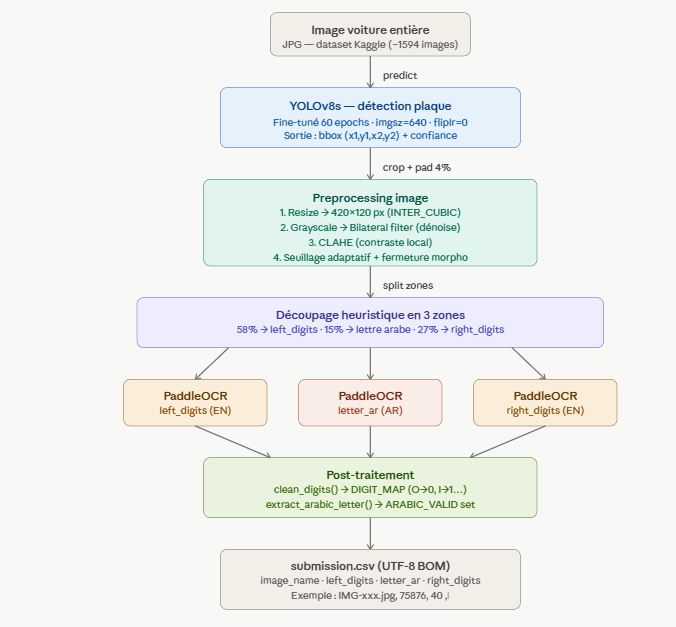

## 📦 Étape 1 — Installation des dépendances

In [ ]:
import torch
print(f'GPU disponible : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')

# Toutes les dépendances
!pip install -q ultralytics
!pip install -q paddlepaddle-gpu 2>/dev/null || pip install -q paddlepaddle
!pip install -q paddleocr
!pip install -q arabic-reshaper python-bidi
!pip install -q kaggle

print('\n✅ Dépendances installées')

GPU disponible : False
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 29.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.4 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.4 which is incompatible.

✅ Dépendances installées


## 📁 Étape 2 — Téléchargement du dataset depuis Kaggle

> **Prérequis** : Avoir un compte Kaggle.
> Récupère ton `username` et ton `API key` depuis : https://www.kaggle.com/settings → API → Create New Token
> (le fichier `kaggle.json` contient ces deux infos — pas besoin de l'uploader)

# Configuration pour se connecté a Kaggle

In [ ]:
import os, json, zipfile
from pathlib import Path

# ══════════════════════════════════════════════════
#  🔑 RENSEIGNER ICI tes identifiants Kaggle
#  (visibles dans kaggle.json après Create New Token)
# ══════════════════════════════════════════════════
KAGGLE_USERNAME = 'malikachaaban'
KAGGLE_API_KEY  = 'KGAT_8b67fa9d4659efb25039391004d9b461'

# Création automatique du fichier kaggle.json
kaggle_dir = Path(os.path.expanduser('~/.kaggle'))
kaggle_dir.mkdir(parents=True, exist_ok=True)
kaggle_json = kaggle_dir / 'kaggle.json'

kaggle_json.write_text(json.dumps({
    'username': KAGGLE_USERNAME,
    'key'     : KAGGLE_API_KEY
}))
kaggle_json.chmod(0o600)

print('✅ Authentification Kaggle configurée')
print(f'   Username : {KAGGLE_USERNAME}')
print(f'   API key  : {KAGGLE_API_KEY[:6]}...{KAGGLE_API_KEY[-4:]}  (masquée)')

✅ Authentification Kaggle configurée
   Username : malikachaaban
   API key  : KGAT_8...b461  (masquée)


In [ ]:
# Téléchargement et extraction du dataset
!kaggle datasets download -d elmehditaf96/moroccan-vehicle-registration-plates -p /content/kaggle_data

# Extraction du zip
zip_path = '/content/drive/MyDrive/full_images.zip'
extract_path = '/content/drive/MyDrive/full_images'
"""
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print('\n📂 Contenu extrait :')
for p in sorted(Path(extract_path).rglob('*'))[:30]:
    print(f'  {p.relative_to(extract_path)}')
print('  ...')"""

Dataset URL: https://www.kaggle.com/datasets/elmehditaf96/moroccan-vehicle-registration-plates
License(s): CC0-1.0
moroccan-vehicle-registration-plates.zip: Skipping, found more recently modified local copy (use --force to force download)


"\nwith zipfile.ZipFile(zip_path, 'r') as z:\n    z.extractall(extract_path)\n\nprint('\n📂 Contenu extrait :')\nfor p in sorted(Path(extract_path).rglob('*'))[:30]:\n    print(f'  {p.relative_to(extract_path)}')\nprint('  ...')"

In [ ]:
# ── Détection automatique de la structure du dataset ─────────
import os
from pathlib import Path

EXTRACT_ROOT = Path('/content/kaggle_data')

# Chercher le dossier contenant les .jpg + .txt
def find_dataset_dir(root):
    for d in sorted(root.rglob('*')):
        if d.is_dir():
            jpgs = list(d.glob('*.jpg'))
            txts = list(d.glob('*.txt'))
            if len(jpgs) > 50 and len(txts) > 50:
                return d
    return None

TRAIN_DIR = find_dataset_dir(EXTRACT_ROOT)

# Chercher le dossier test
TEST_DIR = None
for candidate in ['test_img', 'test', 'Test', 'TEST']:
    for d in EXTRACT_ROOT.rglob(candidate):
        if d.is_dir():
            TEST_DIR = d
            break
    if TEST_DIR:
        break

# Chercher les fichiers config
WEIGHTS   = next(EXTRACT_ROOT.rglob('*.weights'), None)
CFG       = next(EXTRACT_ROOT.rglob('*.cfg'),     None)
OBJ_NAMES = next(EXTRACT_ROOT.rglob('obj.names'), None)

# Résumé
train_imgs = list(TRAIN_DIR.glob('*.jpg')) + list(TRAIN_DIR.glob('*.jpeg')) + list(TRAIN_DIR.glob('*.png')) if TRAIN_DIR else []
test_imgs  = list(TEST_DIR.glob('*.jpg'))  + list(TEST_DIR.glob('*.jpeg'))  + list(TEST_DIR.glob('*.png'))  if TEST_DIR  else []

print(f'TRAIN_DIR  : {TRAIN_DIR}')
print(f'TEST_DIR   : {TEST_DIR}')
print(f'WEIGHTS    : {WEIGHTS}')
print(f'OBJ_NAMES  : {OBJ_NAMES}')
print(f'\nImages train : {len(train_imgs)}')
print(f'Images test  : {len(test_imgs)}')

if OBJ_NAMES:
    classes = OBJ_NAMES.read_text().strip().splitlines()
    print(f'Classes      : {classes}')

# Vérification annotation
sample_txt = list(TRAIN_DIR.glob('*.txt'))[0]
print(f'\nExemple annotation ({sample_txt.name}) :')
print(f'  {sample_txt.read_text().strip()}')
print('  → format : classe cx cy w h (YOLO)')

TRAIN_DIR  : /content/kaggle_data/dataset/dataset
TEST_DIR   : /content/kaggle_data/test_img
WEIGHTS    : /content/kaggle_data/yolov4-obj.weights
OBJ_NAMES  : /content/kaggle_data/obj.names

Images train : 1596
Images test  : 1
Classes      : ['license_plate']

Exemple annotation (IMG-20200728-WA0034.txt) :
  0 0.438281 0.629588 0.664062 0.120133
  → format : classe cx cy w h (YOLO)


## 🔍 Étape 3 — Exploration visuelle du dataset

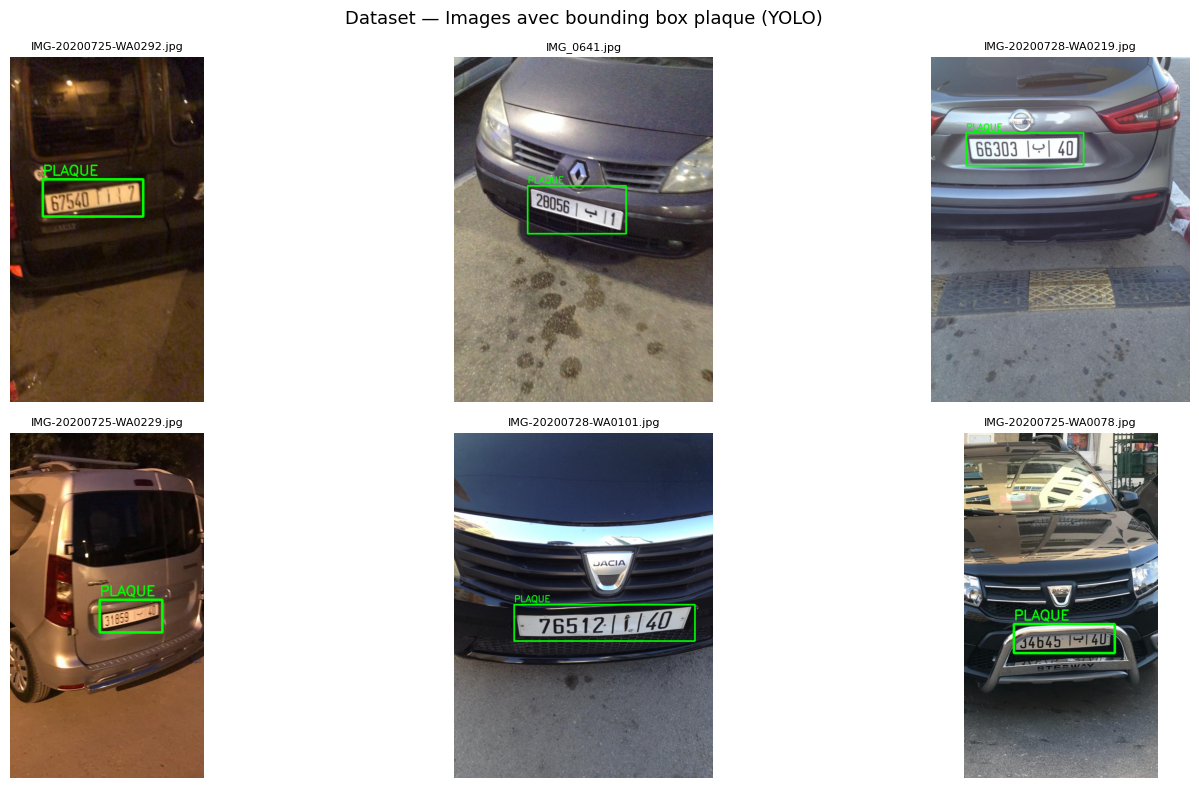

In [ ]:
import cv2, random, matplotlib.pyplot as plt, numpy as np

def draw_yolo_annotation(img_bgr, txt_path):
    """Dessine la bounding box YOLO sur l'image."""
    h, w = img_bgr.shape[:2]
    if not Path(txt_path).exists():
        return img_bgr
    with open(txt_path) as f:
        for line in f:
            p = line.strip().split()
            if len(p) < 5: continue
            cx, cy, bw, bh = float(p[1]), float(p[2]), float(p[3]), float(p[4])
            x1 = int((cx - bw/2) * w); y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w); y2 = int((cy + bh/2) * h)
            cv2.rectangle(img_bgr, (x1,y1), (x2,y2), (0,255,0), 3)
            cv2.putText(img_bgr, 'PLAQUE', (x1, max(y1-8,0)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,0), 2)
    return img_bgr

# 6 exemples aléatoires avec annotations
samples = random.sample(train_imgs, min(6, len(train_imgs)))
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, img_path in zip(axes.flatten(), samples):
    img = cv2.imread(str(img_path))
    img = draw_yolo_annotation(img.copy(), img_path.with_suffix('.txt'))
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(img_path.name, fontsize=8); ax.axis('off')
plt.suptitle('Dataset — Images avec bounding box plaque (YOLO)', fontsize=13)
plt.tight_layout(); plt.show()

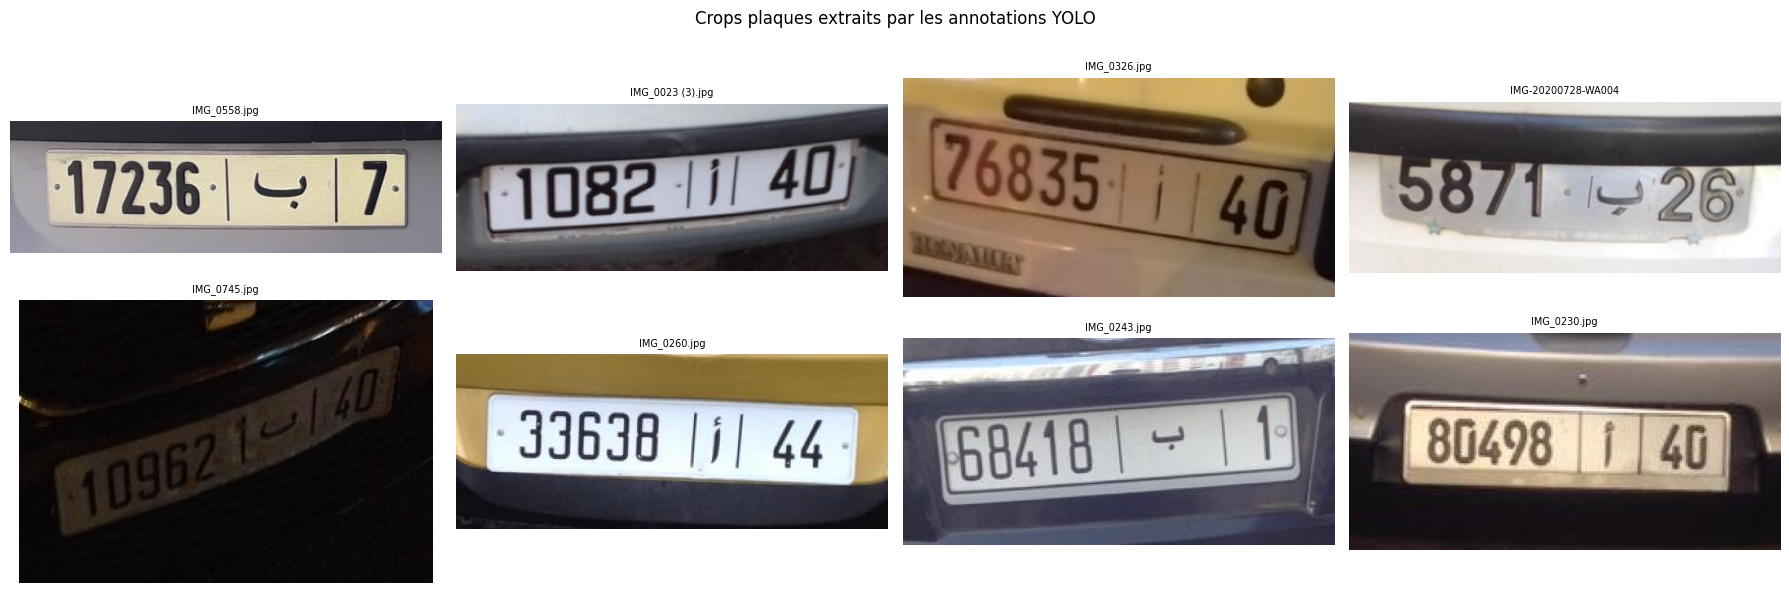

Largeur bbox (% image) — min:0.11  max:0.78  moy:0.40
Hauteur bbox (% image) — min:0.03  max:0.33  moy:0.12


In [ ]:
# Visualiser les crops de plaques — vérifier la qualité et la lisibilité
def crop_from_yolo_txt(img_bgr, txt_path, pad=0.05):
    """Extrait le crop plaque depuis annotation YOLO avec padding."""
    h, w = img_bgr.shape[:2]
    with open(txt_path) as f:
        parts = f.readline().strip().split()
    if len(parts) < 5: return None
    cx, cy, bw, bh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
    bw_p = min(bw + pad, 1.0); bh_p = min(bh + pad, 1.0)
    x1 = max(0, int((cx - bw_p/2) * w)); y1 = max(0, int((cy - bh_p/2) * h))
    x2 = min(w, int((cx + bw_p/2) * w)); y2 = min(h, int((cy + bh_p/2) * h))
    return img_bgr[y1:y2, x1:x2] if x2 > x1 and y2 > y1 else None

# Afficher 8 crops
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
count = 0
for img_path in random.sample(train_imgs, min(40, len(train_imgs))):
    txt = img_path.with_suffix('.txt')
    if not txt.exists() or count >= 8: continue
    img = cv2.imread(str(img_path))
    crop = crop_from_yolo_txt(img, txt)
    if crop is not None and crop.size > 0:
        axes.flatten()[count].imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
        axes.flatten()[count].set_title(img_path.name[:18], fontsize=7)
        axes.flatten()[count].axis('off')
        count += 1
plt.suptitle('Crops plaques extraits par les annotations YOLO', fontsize=12)
plt.tight_layout(); plt.show()

# Stats sur les tailles de boîtes
widths, heights = [], []
for img_path in random.sample(train_imgs, min(200, len(train_imgs))):
    txt = img_path.with_suffix('.txt')
    if not txt.exists(): continue
    p = txt.read_text().strip().split()
    if len(p) >= 5:
        widths.append(float(p[3])); heights.append(float(p[4]))

print(f'Largeur bbox (% image) — min:{min(widths):.2f}  max:{max(widths):.2f}  moy:{sum(widths)/len(widths):.2f}')
print(f'Hauteur bbox (% image) — min:{min(heights):.2f}  max:{max(heights):.2f}  moy:{sum(heights)/len(heights):.2f}')

## 🏋️ Étape 4 — Préparation des données et Fine-tuning YOLOv8s

> On fine-tune **YOLOv8s** (plus moderne et précis que YOLOv4) sur nos ~1581 images.
> Les poids `yolov4-obj.weights` sont fournis dans le dataset — on les laisse de côté
> car YOLOv8 est supérieur et nativement supporté par Ultralytics.

In [ ]:
import yaml, shutil, random
from pathlib import Path

# ── Split train/val 90/10 ─────────────────────────────────────
YOLO_DS = Path('/content/yolo_dataset')
for split in ['train', 'val']:
    (YOLO_DS / split / 'images').mkdir(parents=True, exist_ok=True)
    (YOLO_DS / split / 'labels').mkdir(parents=True, exist_ok=True)

# Garder uniquement les images avec annotation valide
valid_imgs = [p for p in train_imgs if p.with_suffix('.txt').exists()
              and p.with_suffix('.txt').stat().st_size > 0]

random.seed(42)
random.shuffle(valid_imgs)
cut = int(len(valid_imgs) * 0.9)
train_set, val_set = valid_imgs[:cut], valid_imgs[cut:]
print(f'Train : {len(train_set)} | Val : {len(val_set)}')

# Copie des fichiers
for img_path, split in [(p, 'train') for p in train_set] + [(p, 'val') for p in val_set]:
    shutil.copy(img_path,                        YOLO_DS / split / 'images' / img_path.name)
    shutil.copy(img_path.with_suffix('.txt'),    YOLO_DS / split / 'labels' / (img_path.stem + '.txt'))

# data.yaml
data_yaml = {
    'path' : str(YOLO_DS),
    'train': 'train/images',
    'val'  : 'val/images',
    'nc'   : 1,
    'names': ['plate']
}
yaml_path = YOLO_DS / 'data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print('\n✅ Structure YOLOv8 prête')
print(yaml.dump(data_yaml))

Train : 1436 | Val : 160

✅ Structure YOLOv8 prête
names:
- plate
nc: 1
path: /content/yolo_dataset
train: train/images
val: val/images



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!cp -r /content/runs/plates_yolov8 /content/drive/MyDrive/

In [ ]:
from ultralytics import YOLO
import torch

# Fine-tuning YOLOv8s
model_yolo = YOLO('yolov8s.pt')

model_yolo.train(
    data    = str(yaml_path),
    epochs  = 60,
    imgsz   = 640,
    batch   = 16,
    patience= 15,          # early stopping
    device  = 0 if torch.cuda.is_available() else 'cpu',
    project = '/content/runs',
    name    = 'plates_yolov8',
    save    = True,
    verbose = False,
    # ── Augmentations adaptées aux plaques ───
    hsv_h   = 0.015,
    hsv_s   = 0.5,
    hsv_v   = 0.4,
    degrees = 8.0,    # rotation légère (plaques parfois inclinées)
    translate= 0.1,
    scale   = 0.4,
    fliplr  = 0.0,
    mosaic  = 0.8,
    mixup   = 0.1,
)

BEST_WEIGHTS = '/content/runs/plates_yolov8/weights/best.pt'
print(f'\n✅ Entraînement terminé')
print(f'   Meilleur modèle : {BEST_WEIGHTS}')

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset/data.yaml, degrees=8.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=60, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.8, multi_scale=0.0, name=plates_yolov8-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, pati

Ultralytics 8.4.41 🚀 Python-3.12.13 torch-2.10.0+cpu CPU (Intel Xeon CPU @ 2.20GHz)
Model summary (fused): 73 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1539.2±500.4 MB/s, size: 137.1 KB)
val: Scanning /content/yolo_dataset/val/labels... 160 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 160/160 803.9it/s 0.2s
val: New cache created: /content/yolo_dataset/val/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 12.2s/it 2:02
                   all        160        160      0.994          1      0.995      0.834
Speed: 11.0ms preprocess, 718.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Results saved to /content/runs/detect/val
📊 Métriques de détection (val set) :
   mAP@50    : 0.9949
   mAP@50-95 : 0.8335
   Précision : 0.9938
   Rappel    : 0.9999


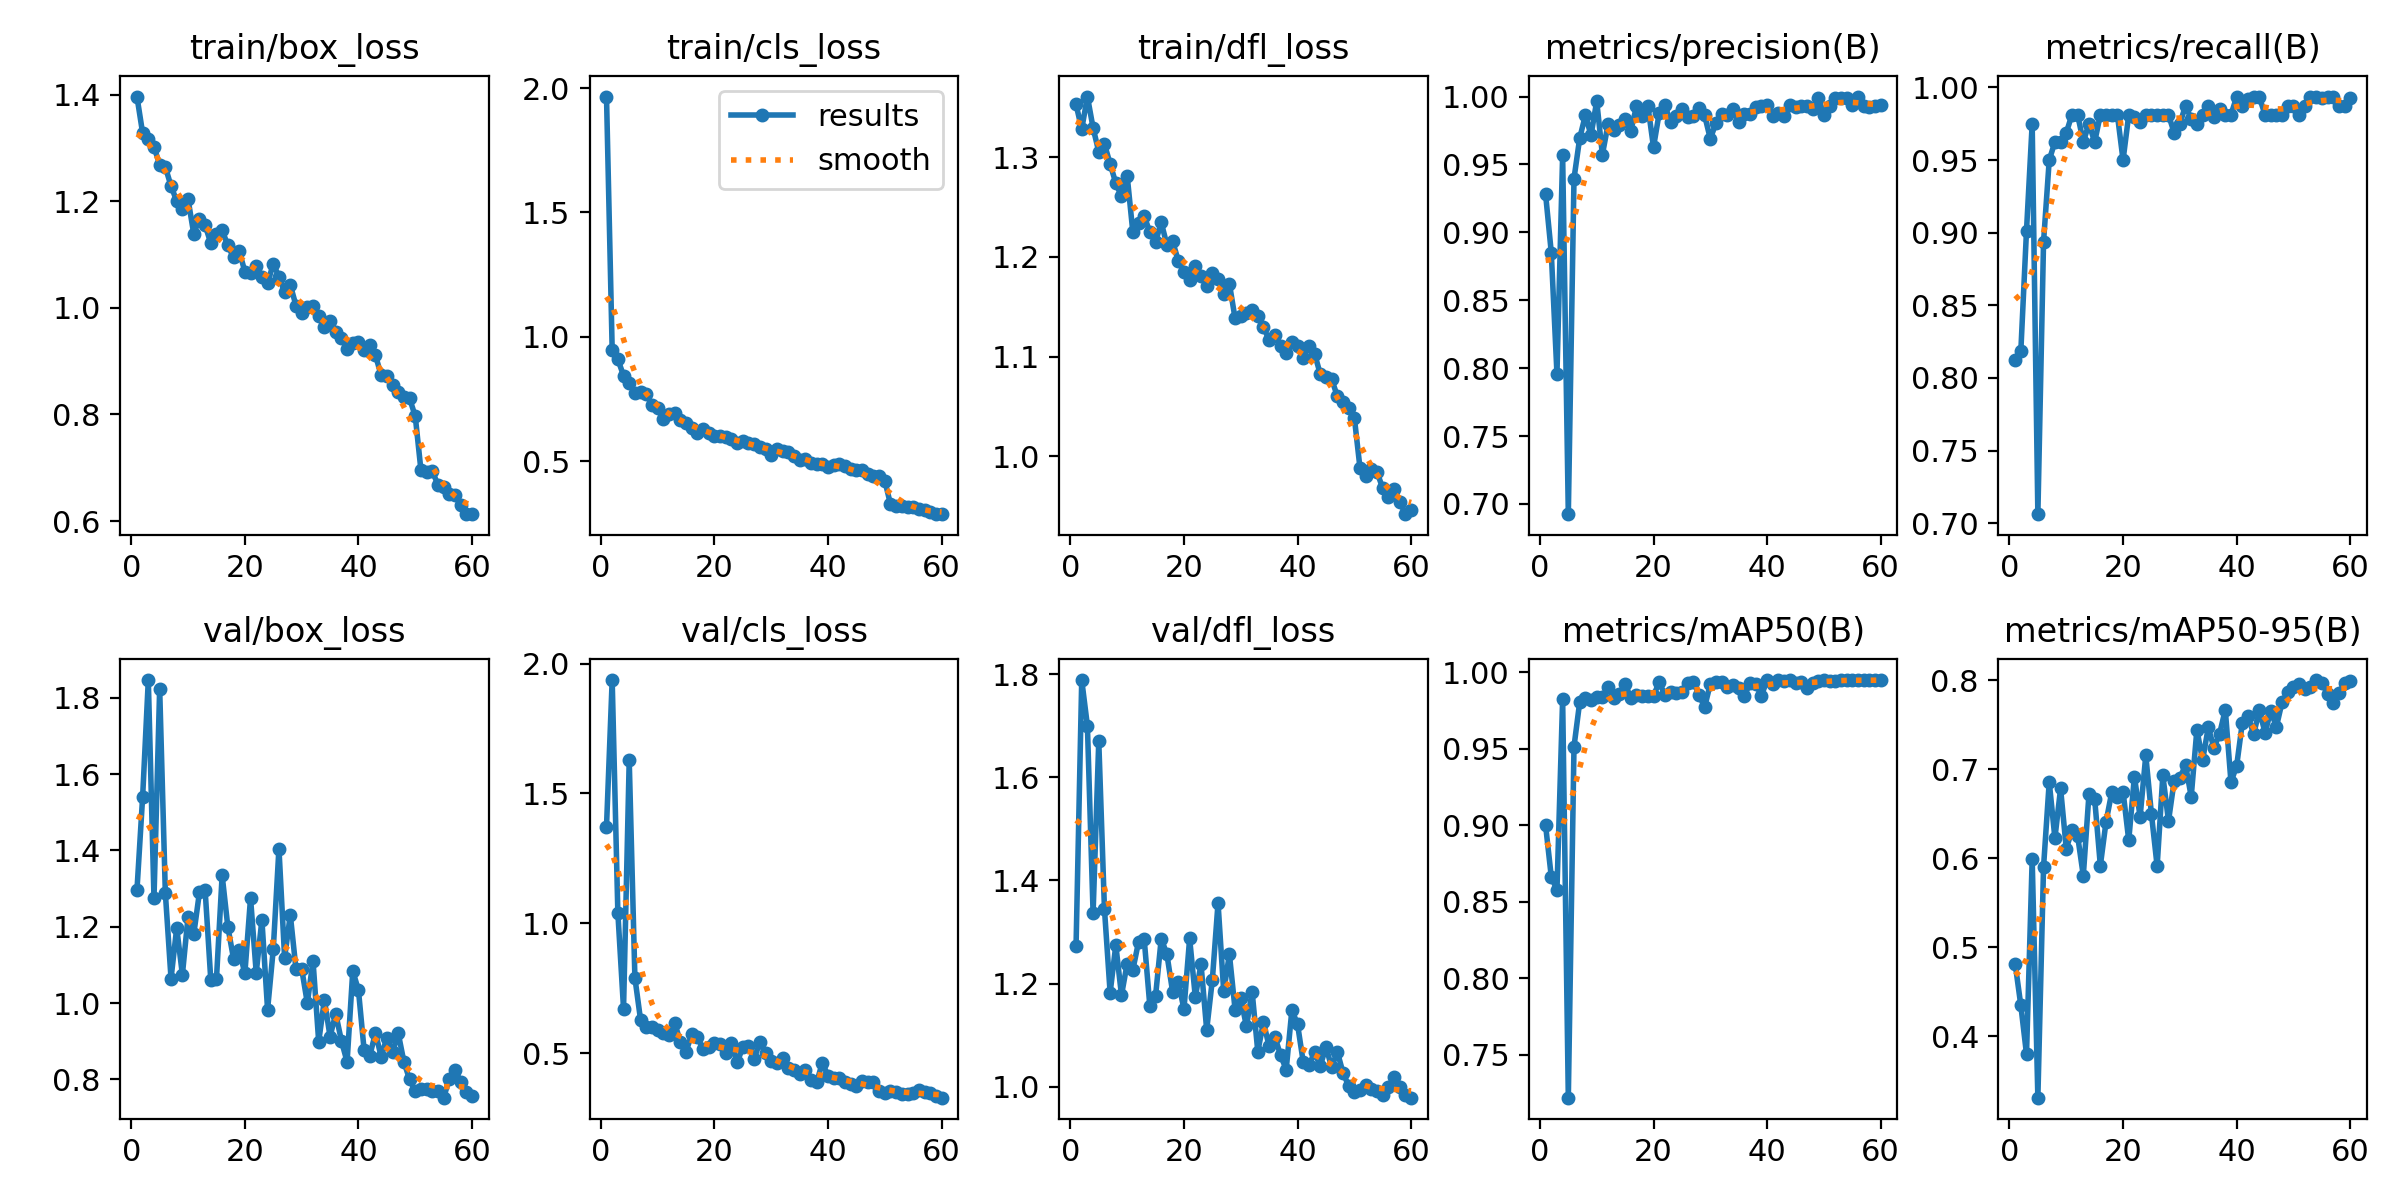

In [ ]:
from ultralytics import YOLO
import torch
model_yolo = YOLO('yolov8s.pt')
BEST_WEIGHTS = '/content/drive/MyDrive/plates_yolov8/weights/best.pt'
# Évaluation sur val set
detector = YOLO(BEST_WEIGHTS)
metrics  = detector.val(data=str(yaml_path), verbose=False)

print('📊 Métriques de détection (val set) :')
print(f'   mAP@50    : {metrics.box.map50:.4f}')
print(f'   mAP@50-95 : {metrics.box.map:.4f}')
print(f'   Précision : {metrics.box.mp:.4f}')
print(f'   Rappel    : {metrics.box.mr:.4f}')

from IPython.display import Image as IPImage
IPImage('/content/drive/MyDrive/plates_yolov8/results.png', width=900)

## 🔤 Étape 5 — Configuration PaddleOCR

In [ ]:
# ---------------------------------------------------------
# 1. INSTALLATION
# ---------------------------------------------------------

!pip uninstall -y paddlepaddle paddlex paddleocr -q
!pip install paddlepaddle==2.6.2 -q
!pip install paddleocr==2.7.3 -q
!pip install "numpy==1.26.4" -q

# Restart runtime après cette cellule !

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.9/125.9 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.0/780.0 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.0/948.0 kB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.1/333.1 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 123.9/123.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 14.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 99.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [ ]:
# ---------------------------------------------------------
# 2. VÉRIFICATION (cellule optionnelle)
# ---------------------------------------------------------

import numpy as np
import paddle
from paddleocr import PaddleOCR

print("numpy  :", np.__version__)       # doit afficher 1.26.4
print("paddle :", paddle.__version__)   # doit afficher 2.6.2
print("✅ Versions OK")

numpy  : 1.26.4
paddle : 2.6.2
✅ Versions OK


In [ ]:
# ---------------------------------------------------------
# 3. INITIALISATION OCR
# ---------------------------------------------------------

ocr = PaddleOCR(
    use_angle_cls=True,
    lang='ar',
    use_gpu=False,
    show_log=False
)

print("✅ PaddleOCR initialisé avec succès")

download https://paddleocr.bj.bcebos.com/PP-OCRv3/multilingual/Multilingual_PP-OCRv3_det_infer.tar to /root/.paddleocr/whl/det/ml/Multilingual_PP-OCRv3_det_infer/Multilingual_PP-OCRv3_det_infer.tar


100%|██████████| 3.85M/3.85M [00:17<00:00, 219kiB/s]


download https://paddleocr.bj.bcebos.com/PP-OCRv4/multilingual/arabic_PP-OCRv4_rec_infer.tar to /root/.paddleocr/whl/rec/arabic/arabic_PP-OCRv4_rec_infer/arabic_PP-OCRv4_rec_infer.tar


100%|██████████| 7.92M/7.92M [00:34<00:00, 228kiB/s]


download https://paddleocr.bj.bcebos.com/dygraph_v2.0/ch/ch_ppocr_mobile_v2.0_cls_infer.tar to /root/.paddleocr/whl/cls/ch_ppocr_mobile_v2.0_cls_infer/ch_ppocr_mobile_v2.0_cls_infer.tar


100%|██████████| 2.19M/2.19M [00:20<00:00, 107kiB/s]


✅ PaddleOCR initialisé avec succès


In [ ]:
import pandas as pd
import cv2
import re
import numpy as np
from pathlib import Path
from tqdm import tqdm
from ultralytics import YOLO
from paddleocr import PaddleOCR

"""
image → YOLO crop → preprocessing → split 3 zones → OCR → correction
                                                         ↓
                                          (left, lettre, right)"""


# ── CHEMINS ───────────────────────────────────────────────────
EVAL_DIR     = Path("/content/kaggle_data/dataset/dataset")
YOLO_WEIGHTS = '/content/drive/MyDrive/plates_yolov8/weights/best.pt'
OUTPUT_CSV   = '/content/submission.csv'

# ── MODÈLES ───────────────────────────────────────────────────
detector = YOLO(YOLO_WEIGHTS)
ocr = PaddleOCR(use_angle_cls=True, lang='ar', use_gpu=False, show_log=False)
print("✅ YOLO + OCR initialisés")

# ── CONSTANTES ────────────────────────────────────────────────
DIGIT_MAP = {
    'O':'0','o':'0','D':'0','Q':'0','C':'0',
    'I':'1','l':'1','|':'1','!':'1','i':'1',
    'Z':'2','z':'2','E':'3','A':'4','h':'4',
    'S':'5','s':'5','G':'6','b':'6','T':'7',
    'B':'8','g':'9','q':'9','P':'9',
}
ARABIC_VALID = set('أبتثجحخدذرزسشصضطظعغفقكلمنهوي')

# ── FONCTIONS ─────────────────────────────────────────────────
def clean_digits(text):
    corrected = ''.join(DIGIT_MAP.get(c, c) for c in str(text or ''))
    return re.sub(r'[^0-9]', '', corrected)

def extract_arabic_letter(text):
    for ch in str(text or ''):
        if ch in ARABIC_VALID:
            return ch
    return ''

def run_ocr(img_array, conf_thresh=0.15):
    if img_array is None or img_array.size == 0:
        return ''
    try:
        result = ocr.ocr(img_array, cls=True)
        if result and result[0]:
            return ' '.join(
                line[1][0] for line in result[0]
                if line[1][1] >= conf_thresh
            )
    except:
        pass
    return ''

def preprocess_plate(crop, target_w=420, target_h=120):
    if crop is None or crop.size == 0:
        return None
    resized  = cv2.resize(crop, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
    gray     = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    denoised = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(denoised)
    thresh   = cv2.adaptiveThreshold(enhanced, 255,
                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 4)
    kernel   = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned  = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    return cv2.cvtColor(cleaned, cv2.COLOR_GRAY2BGR)

def detect_plate_crop(img_bgr, conf=0.25, pad=0.04):
    h, w = img_bgr.shape[:2]
    res  = detector.predict(img_bgr, conf=conf, verbose=False)
    boxes = res[0].boxes
    if boxes is not None and len(boxes) > 0:
        best = max(boxes, key=lambda b: float(b.conf[0]))
        x1,y1,x2,y2 = map(int, best.xyxy[0])
        px = int((x2-x1)*pad); py = int((y2-y1)*pad)
        x1,y1 = max(0,x1-px), max(0,y1-py)
        x2,y2 = min(w,x2+px), min(h,y2+py)
        return img_bgr[y1:y2, x1:x2]
    return img_bgr

def predict_plate(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return '', '', ''
    crop       = detect_plate_crop(img)
    plate_proc = preprocess_plate(crop)
    if plate_proc is None:
        return '', '', ''
    h, w = plate_proc.shape[:2]
    z_left   = plate_proc[:, :int(w*0.58)]
    z_letter = plate_proc[:, int(w*0.58):int(w*0.73)]
    z_right  = plate_proc[:, int(w*0.73):]
    left_digits  = clean_digits(run_ocr(z_left))
    letter_ar    = extract_arabic_letter(run_ocr(z_letter))
    right_digits = clean_digits(run_ocr(z_right))
    if not letter_ar:
        letter_ar = extract_arabic_letter(run_ocr(plate_proc))
    return left_digits, letter_ar, right_digits

# ── BOUCLE ────────────────────────────────────────────────────
eval_images = sorted(
    list(EVAL_DIR.glob('*.jpg'))  +
    list(EVAL_DIR.glob('*.jpeg')) +
    list(EVAL_DIR.glob('*.png'))
)
print(f"📂 {len(eval_images)} images à traiter...")

records = []
for img_path in tqdm(eval_images, desc='OCR plaques'):
    try:
        l, le, r = predict_plate(img_path)
    except Exception as e:
        print(f"⚠️ {img_path.name}: {e}")
        l, le, r = '', '', ''
    records.append({
        'image_name'  : img_path.name,
        'left_digits' : l,
        'letter_ar'   : le,
        'right_digits': r
    })

# ── SAUVEGARDE ────────────────────────────────────────────────
df = pd.DataFrame(records, columns=['image_name','left_digits','letter_ar','right_digits'])
df['letter_ar'] = df['letter_ar'].astype(str).apply(lambda x: x[0] if x.strip() else '')
df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

print(f"\n✅ {len(df)} plaques traitées")
print(f"   Left vide   : {(df['left_digits']  == '').sum()}")
print(f"   Lettre vide : {(df['letter_ar']    == '').sum()}")
print(f"   Right vide  : {(df['right_digits'] == '').sum()}")
display(df.head(10))

from google.colab import files
files.download(OUTPUT_CSV)
print("📥 submission.csv téléchargé !")

✅ YOLO + OCR initialisés
📂 1596 images à traiter...


OCR plaques: 100%|██████████| 1596/1596 [28:30<00:00,  1.07s/it]


✅ 1596 plaques traitées
   Left vide   : 286
   Lettre vide : 1025
   Right vide  : 1432


,image_name,left_digits,letter_ar,right_digits
0,IMG-20200725-WA0000.jpg,758,,
1,IMG-20200725-WA0001.jpg,9462,ك,
2,IMG-20200725-WA0002.jpg,73,أ,
3,IMG-20200725-WA0004.jpg,07811,,
4,IMG-20200725-WA0037.jpg,467,أ,
5,IMG-20200725-WA0038.jpg,6311,,
6,IMG-20200725-WA0039.jpg,51122,,
7,IMG-20200725-WA0040.jpg,587451,,
8,IMG-20200725-WA0042.jpg,61991,ب,
9,IMG-20200725-WA0043.jpg,54,ر,


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 submission.csv téléchargé !


In [ ]:
!cp -r /content/submission.csv /content/drive/MyDrive/

In [ ]:
# ══════════════════════════════════════════════════════════════
#           ÉVALUATION FINALE — 25 Avril 2026
# ══════════════════════════════════════════════════════════════

# ── 0. Imports ───────────────────────────────────────────────
from ultralytics import YOLO
from paddleocr import PaddleOCR
import pandas as pd
import cv2
import numpy as np
import re
from pathlib import Path
from tqdm import tqdm
from google.colab import files

# ── 1. CONFIGURER CES 2 CHEMINS ──────────────────────────────
EVAL_DIR    = Path('/content/drive/MyDrive/full_images')   # ← CHANGER par le dossier fourni
YOLO_WEIGHTS = '/content/drive/MyDrive/plates_yolov8/weights/best.pt'
OUTPUT_CSV  = '/content/submission.csv'

# ── 2. Initialisation modèles ─────────────────────────────────
detector = YOLO(YOLO_WEIGHTS)

ocr = PaddleOCR(
    use_angle_cls=True,
    lang='ar',
    use_gpu=False,
    show_log=False
)
print("✅ YOLO + OCR initialisés")

# ── 3. Fonctions pipeline ─────────────────────────────────────
DIGIT_MAP = {
    'O':'0','o':'0','D':'0','Q':'0','C':'0',
    'I':'1','l':'1','|':'1','!':'1','i':'1',
    'Z':'2','z':'2','E':'3','A':'4','h':'4',
    'S':'5','s':'5','G':'6','b':'6','T':'7',
    'B':'8','g':'9','q':'9','P':'9',
}
ARABIC_VALID = set('أبتثجحخدذرزسشصضطظعغفقكلمنهوي')

def clean_digits(text):
    corrected = ''.join(DIGIT_MAP.get(c, c) for c in str(text or ''))
    return re.sub(r'[^0-9]', '', corrected)

def extract_arabic_letter(text):
    for ch in str(text or ''):
        if ch in ARABIC_VALID:
            return ch
    return ''

def run_ocr(img_array, conf_thresh=0.15):
    if img_array is None or img_array.size == 0:
        return ''
    try:
        result = ocr.ocr(img_array, cls=True)
        if result and result[0]:
            return ' '.join(
                line[1][0] for line in result[0]
                if line[1][1] >= conf_thresh
            )
    except Exception as e:
        print("OCR error:", e)
    return ''

def preprocess_plate(crop, target_w=420, target_h=120):
    if crop is None or crop.size == 0:
        return None
    resized  = cv2.resize(crop, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
    gray     = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    denoised = cv2.bilateralFilter(gray, d=9, sigmaColor=75, sigmaSpace=75)
    clahe    = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    enhanced = clahe.apply(denoised)
    thresh   = cv2.adaptiveThreshold(enhanced, 255,
                   cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 15, 4)
    kernel   = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    cleaned  = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel)
    return cv2.cvtColor(cleaned, cv2.COLOR_GRAY2BGR)

def detect_plate_crop(img_bgr, conf=0.25, pad=0.04):
    h, w = img_bgr.shape[:2]
    res   = detector.predict(img_bgr, conf=conf, verbose=False)
    boxes = res[0].boxes
    if boxes is not None and len(boxes) > 0:
        best = max(boxes, key=lambda b: float(b.conf[0]))
        x1,y1,x2,y2 = map(int, best.xyxy[0])
        px = int((x2-x1)*pad); py = int((y2-y1)*pad)
        x1,y1 = max(0,x1-px), max(0,y1-py)
        x2,y2 = min(w,x2+px), min(h,y2+py)
        return img_bgr[y1:y2, x1:x2]
    return img_bgr  # fallback image entière

def predict_plate(img_path):
    img = cv2.imread(str(img_path))
    if img is None:
        return '', '', ''
    crop       = detect_plate_crop(img)
    plate_proc = preprocess_plate(crop)
    if plate_proc is None:
        return '', '', ''
    h, w = plate_proc.shape[:2]
    z_left   = plate_proc[:, :int(w*0.58)]
    z_letter = plate_proc[:, int(w*0.58):int(w*0.73)]
    z_right  = plate_proc[:, int(w*0.73):]

    left_digits  = clean_digits(run_ocr(z_left))
    letter_ar    = extract_arabic_letter(run_ocr(z_letter))
    right_digits = clean_digits(run_ocr(z_right))

    # Fallback lettre : OCR sur plaque entière si zone vide
    if not letter_ar:
        letter_ar = extract_arabic_letter(run_ocr(plate_proc))

    return left_digits, letter_ar, right_digits

# ── 4. Traitement ─────────────────────────────────────────────
eval_images = sorted(
    list(EVAL_DIR.glob('*.jpg'))  +
    list(EVAL_DIR.glob('*.jpeg')) +
    list(EVAL_DIR.glob('*.png'))
)
print(f"🔍 {len(eval_images)} images à traiter...")

records = []
for img_path in tqdm(eval_images, desc='OCR plaques'):
    try:
        l, le, r = predict_plate(img_path)
    except Exception as e:
        print(f"⚠️ Erreur {img_path.name}: {e}")
        l, le, r = '', '', ''
    records.append({
        'image_name'  : img_path.name,
        'left_digits' : l,
        'letter_ar'   : le,
        'right_digits': r
    })

# ── 5. Export ─────────────────────────────────────────────────
df = pd.DataFrame(records, columns=['image_name','left_digits','letter_ar','right_digits'])
df['letter_ar'] = df['letter_ar'].astype(str).apply(lambda x: x[0] if x.strip() else '')
df.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')

print(f"\n✅ {len(df)} plaques traitées")
print(f"   Left vide   : {(df['left_digits']=='').sum()}")
print(f"   Lettre vide : {(df['letter_ar']=='').sum()}")
print(f"   Right vide  : {(df['right_digits']=='').sum()}")
display(df.head(10))

files.download(OUTPUT_CSV)
print("📥 submission.csv téléchargé !")

✅ YOLO + OCR initialisés
🔍 7194 images à traiter...


OCR plaques: 100%|██████████| 7194/7194 [2:01:37<00:00,  1.01s/it]


✅ 7194 plaques traitées
   Left vide   : 2705
   Lettre vide : 5288
   Right vide  : 6833


,image_name,left_digits,letter_ar,right_digits
0,1.jpg,,,
1,10.jpg,,,
2,100.jpg,55,,
3,1000.jpg,12,,
4,10001.jpg,3597,,
5,10003.jpg,554,,
6,10004.jpg,2452,د,
7,10006.jpg,7541,,
8,1001.jpg,742,,
9,10011.jpg,530,,


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 submission.csv téléchargé !
